# Abundance benchmarking

Quantitative abundance accuracy of each tool vs. the manufacturer-defined
Zymo D6331 ground truth, at species + genus rank, using three concordance
metrics:

- Spearman's rank correlation (ρ)
- 1 − Bray-Curtis dissimilarity
- 1 − Jensen-Shannon divergence

Plus stacked relative-abundance bar plots vs. the theoretical composition.

**Inputs** (produced by `scripts/analysis/analysis_prep.py`):
- `results/metadata/<ts>/analysis-prep/preprocessed/abundance/<Tool>_<db>/<file>.csv`
- `results/metadata/<ts>/analysis-prep/ground_truth/zymoD6331_gt.csv`


## 1. Imports

In [1]:
import os, sys
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# Anchor cwd to bakeoff/ regardless of where the notebook is executed from.
BAKEOFF_ROOT = next(
    (d for d in [Path.cwd(), *Path.cwd().parents]
     if (d / 'config' / 'bakeoff_env.yaml').is_file()),
    None,
)
if BAKEOFF_ROOT is None:
    raise RuntimeError(f'Could not locate bakeoff/ root from {Path.cwd()}')
os.chdir(BAKEOFF_ROOT)
sys.path.insert(0, str(BAKEOFF_ROOT / 'scripts' / 'analysis'))

from utils.util import apply_taxid_synonyms
from utils.results import find_latest_analysis_prep_ts, save_csv, save_fig
sns.set(style='whitegrid')
print(f'bakeoff root: {BAKEOFF_ROOT}')


bakeoff root: /home/Users/pacbio_bakeoff/bakeoff


## 2. Configuration

In [2]:
SAVE = False

RESULTS_ROOT = BAKEOFF_ROOT / 'results'
TS           = find_latest_analysis_prep_ts(RESULTS_ROOT)  # or pin: TS = "YYYYMMDD_HHMMSS"
PREP_DIR     = RESULTS_ROOT / 'metadata' / TS / 'analysis-prep'
ABUND_DIR    = PREP_DIR / 'preprocessed' / 'abundance'
GT_DIR       = PREP_DIR / 'ground_truth'

MIN_ABUNDANCE = 0.0    # drop taxa < this (%); 0 keeps all (paper default)
RANKS         = ['species', 'genus']
SYNONYM_TAXID_MAP = {1578: 2742598}    # collapse synonymous taxa

# --- Dataset selector --- (abundance benchmarking is mock D6331 only) ---
DATASET = 'pacbio_low_input'
DATASETS = {
    # Each entry: project, technology, sample (raw, as in the report tree)
    # plus an optional `title` override for figure labels.
    'ont_zymo_kit':          dict(project='ZymoMockD6331', technology='ont',    sample='D6331_Zymo',    title='ZymoMockD6331 ONT Zymo prep'),
    'ont_qiagen_kit':        dict(project='ZymoMockD6331', technology='ont',    sample='D6331_Qiagen',  title='ZymoMockD6331 ONT Qiagen prep'),
    'pacbio_low_input':      dict(project='ZymoMockD6331', technology='pacbio', sample='SRR13128013',   title='ZymoMockD6331 PacBio low input'),
    'pacbio_standard_input': dict(project='ZymoMockD6331', technology='pacbio', sample='SRR13128014',   title='ZymoMockD6331 PacBio standard input'),
}
if DATASET not in DATASETS:
    raise ValueError(f'Unknown DATASET={DATASET!r}; choose from {sorted(DATASETS)}')
PROJECT, TECHNOLOGY, SAMPLE = (DATASETS[DATASET][k] for k in ('project', 'technology', 'sample'))
SAMPLE_LABEL  = f'{PROJECT}_{TECHNOLOGY}_{SAMPLE}'         # used in paths + filenames
DISPLAY_TITLE = DATASETS[DATASET].get('title', SAMPLE_LABEL)  # used in figure titles
PREP_FNAME    = f'{SAMPLE_LABEL}.csv'

TOOLS = [
    'Centrifuge_unified',  'Centrifuge_default',
    'Centrifuger_unified', 'Centrifuger_default',
    'Kraken2_unified',     'Kraken2_default',
    'Ganon2_unified',      'Ganon2_default',
    'Sourmash_unified',    'Sourmash_default',
    'Sylph_unified',       'Sylph_default',
]
ORDER_TOOLDB = [
    'Centrifuge_default',  'Centrifuge_unified',
    'Centrifuger_default', 'Centrifuger_unified',
    'Kraken2_default',     'Kraken2_unified',
    'Ganon2_default',      'Ganon2_unified',
    'Sourmash_default',    'Sourmash_unified',
    'Sylph_default',       'Sylph_unified',
]

THRESHOLD_DIR = RESULTS_ROOT / TS / 'abundance' / f'threshold_{MIN_ABUNDANCE}' / SAMPLE_LABEL
TABLES_DIR    = THRESHOLD_DIR / 'tables'
FIGURES_DIR   = THRESHOLD_DIR / 'figures'

print(f'{DATASET} -> {SAMPLE_LABEL}   MIN_ABUNDANCE={MIN_ABUNDANCE}%')
print(f'ts:   {TS}')
print(f'PREP: {PREP_DIR}')
print(f'OUT:  {THRESHOLD_DIR}  (SAVE={SAVE})')


pacbio_low_input -> ZymoMockD6331_pacbio_SRR13128013   MIN_ABUNDANCE=0.0%
ts:   20260531_212522
PREP: /home/Users/pacbio_bakeoff/bakeoff/results/metadata/20260531_212522/analysis-prep
OUT:  /home/Users/pacbio_bakeoff/bakeoff/results/20260531_212522/abundance/threshold_0.0/ZymoMockD6331_pacbio_SRR13128013  (SAVE=False)


## 3. Ground truth

In [3]:
GT_FILE = GT_DIR / 'zymoD6331_gt.csv'
if not GT_FILE.is_file():
    raise FileNotFoundError(f'Ground truth missing: {GT_FILE} (run analysis_prep.py first)')

unified_gt = pd.read_csv(GT_FILE)
species_gt = unified_gt.query('rank == "species"').reset_index(drop=True)
genus_gt   = unified_gt.query('rank == "genus"').reset_index(drop=True)
print(f'truth: {GT_FILE.name}  species={len(species_gt)}  genus={len(genus_gt)}')


truth: zymoD6331_gt.csv  species=17  genus=17


## 4. Load preprocessed per-tool tables

In [4]:
# Load preprocessed CSVs (one per tool_db); skip ones missing on disk.
tool_tables_all = {
    t: pd.read_csv(ABUND_DIR / t / PREP_FNAME)
    for t in TOOLS
    if (ABUND_DIR / t / PREP_FNAME).is_file()
}
missing = [t for t in TOOLS if t not in tool_tables_all]
TOOLS = list(tool_tables_all)
print(f'loaded {len(TOOLS)} tool tables; missing: {missing or "none"}')

EMPTY = pd.DataFrame(columns=['taxid', 'name', 'abundance'])

def _prep_abundance(df, rank):
    """Return df at this rank with cleaned taxid + abundance (= 'norm_abund' col)."""
    df = df.query('rank == @rank').copy()
    if df.empty:
        return EMPTY.copy()
    df['taxid']     = pd.to_numeric(df['taxid'], errors='coerce').astype('Int64')
    df['abundance'] = pd.to_numeric(df['norm_abund'], errors='coerce').fillna(0.0)
    df = df.dropna(subset=['taxid']).reset_index(drop=True)
    if 'name' not in df.columns:
        df['name'] = df['taxid'].astype(str)
    return df[['taxid', 'name', 'abundance']]

def _filter_min(df, label):
    if df.empty or MIN_ABUNDANCE <= 0:
        return df
    before = len(df)
    out = df[df['abundance'] >= MIN_ABUNDANCE].reset_index(drop=True)
    print(f'  {label}: {before} -> {len(out)} (>= {MIN_ABUNDANCE}%)')
    return out

all_results = {}
for rank in RANKS:
    print(f'\n=== rank: {rank} ===')

    # Ground truth at this rank
    gt_src = species_gt if rank == 'species' else genus_gt
    gt = gt_src[['taxid', 'name', 'abundance']].copy()
    gt['taxid']     = pd.to_numeric(gt['taxid'], errors='coerce').astype('Int64')
    gt['abundance'] = pd.to_numeric(gt['abundance'], errors='coerce').fillna(0.0)
    gt = gt.dropna(subset=['taxid']).reset_index(drop=True)
    gt = apply_taxid_synonyms(gt, synonyms=SYNONYM_TAXID_MAP, collapse=True,
                              source_label=f'GT_{rank}')
    gt = _filter_min(gt, 'GT')
    print(f'  GT taxa: {len(gt)}')

    # Per-tool tables: synonym-mapped, then optionally filtered.
    tools_norm, tools_filtered = {}, {}
    for tool_db in TOOLS:
        df = _prep_abundance(tool_tables_all[tool_db], rank)
        if df.empty:
            tools_norm[tool_db] = tools_filtered[tool_db] = EMPTY.copy()
            print(f'  {tool_db}: no rows')
            continue
        df = apply_taxid_synonyms(df, synonyms=SYNONYM_TAXID_MAP, collapse=True,
                                  source_label=f'{tool_db}_{rank}')
        tools_norm[tool_db]     = df.copy()
        tools_filtered[tool_db] = _filter_min(df, tool_db)
        if MIN_ABUNDANCE <= 0:
            print(f'  {tool_db}: {len(df)} taxa')

    all_results[rank] = {'gt': gt, 'tools': tools_filtered, 'tools_raw': tools_norm}
    print(f'  stored {len(tools_filtered)} tool tables')


loaded 12 tool tables; missing: none

=== rank: species ===
  GT taxa: 17
  Centrifuge_unified: 1843 taxa
  Centrifuge_default: 2569 taxa
  Centrifuger_unified: 102 taxa
  Centrifuger_default: 2155 taxa
  Kraken2_unified: 292 taxa
  Kraken2_default: 956 taxa
  Ganon2_unified: 32 taxa
  Ganon2_default: 30 taxa
  Sourmash_unified: 18 taxa
  Sourmash_default: 26 taxa
  Sylph_unified: 17 taxa
  Sylph_default: 14 taxa
  stored 12 tool tables

=== rank: genus ===
  GT taxa: 17
[Synonyms:Centrifuge_unified_genus] 1 taxids replaced (examples: {np.int64(1578): 2742598})
  Centrifuge_unified: 685 taxa
[Synonyms:Centrifuge_default_genus] 1 taxids replaced (examples: {np.int64(1578): 2742598})
  Centrifuge_default: 874 taxa
  Centrifuger_unified: 49 taxa
[Synonyms:Centrifuger_default_genus] 1 taxids replaced (examples: {np.int64(1578): 2742598})
  Centrifuger_default: 879 taxa
  Kraken2_unified: 97 taxa
[Synonyms:Kraken2_default_genus] 1 taxids replaced (examples: {np.int64(1578): 2742598})
  Krak

## 5. Sanity check (presence/absence)

In [5]:
# Sanity check: presence/absence metrics from ALL abundances
# (does NOT affect abundance analysis)

def compute_presence_dict(df, threshold=0.0):
    """
    Convert a dataframe with columns (taxid, abundance, name) into
    a presence dictionary based on abundance > threshold.
    """
    if df is None or len(df) == 0:
        return {}

    df = df.copy()
    df["abundance"] = pd.to_numeric(df["abundance"], errors="coerce").fillna(0.0)

    present = df[df["abundance"] > threshold]["taxid"].astype(int).tolist()
    return {int(t): True for t in present}

def prf_count_dict(pred_present, truth_present):
    """
    pred_present and truth_present are dicts: {taxid: True}
    Taxa universe = union of both sets.
    """
    all_taxa = set(pred_present.keys()) | set(truth_present.keys())

    TP = FP = FN = TN = 0
    for tax in all_taxa:
        p = tax in pred_present
        t = tax in truth_present

        if p and t:
            TP += 1
        elif p and not t:
            FP += 1
        elif (not p) and t:
            FN += 1
        else:
            TN += 1

    return TP, FP, FN, TN

def prf_score(TP, FP, FN):
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = 2*precision*recall / (precision+recall) if (precision+recall)>0 else 0.0
    return precision, recall, f1

# Run sanity checks for each rank

sanity_results = {}

for rank in RANKS:
    print("\n" + "="*70)
    print(f" SANITY CHECK — {rank.upper()} (threshold > 0 abundance)")
    print("="*70)

    gt_df = all_results[rank]["gt"]
    tools_raw = all_results[rank]["tools_raw"]

    # Build ground-truth presence dictionary
    truth_present = compute_presence_dict(gt_df, threshold=0.0)

    rows = []

    for tool_name, df in tools_raw.items():
        pred_present = compute_presence_dict(df, threshold=0.0)

        TP, FP, FN, TN = prf_count_dict(pred_present, truth_present)
        prec, rec, f1 = prf_score(TP, FP, FN)

        rows.append({
            "tool": tool_name,
            "TP": TP,
            "FP": FP,
            "FN": FN,
            "TN": TN,
            "precision": prec,
            "recall": rec,
            "F1": f1,
        })

        print(f"{tool_name:20s} TP={TP:3d}  FP={FP:3d}  FN={FN:3d}  TN={TN:3d}  "
              f"Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}")

    sanity_df = pd.DataFrame(rows).sort_values("tool").reset_index(drop=True)
    sanity_results[rank] = sanity_df

    print("\nSummary Table:")
    display(sanity_df)



 SANITY CHECK — SPECIES (threshold > 0 abundance)
Centrifuge_unified   TP= 16  FP=189  FN=  1  TN=  0  Prec=0.078  Rec=0.941  F1=0.144
Centrifuge_default   TP= 10  FP=  6  FN=  7  TN=  0  Prec=0.625  Rec=0.588  F1=0.606
Centrifuger_unified  TP= 15  FP= 25  FN=  2  TN=  0  Prec=0.375  Rec=0.882  F1=0.526
Centrifuger_default  TP= 14  FP= 46  FN=  3  TN=  0  Prec=0.233  Rec=0.824  F1=0.364
Kraken2_unified      TP= 15  FP= 24  FN=  2  TN=  0  Prec=0.385  Rec=0.882  F1=0.536
Kraken2_default      TP= 13  FP= 25  FN=  4  TN=  0  Prec=0.342  Rec=0.765  F1=0.473
Ganon2_unified       TP= 17  FP= 15  FN=  0  TN=  0  Prec=0.531  Rec=1.000  F1=0.694
Ganon2_default       TP= 16  FP= 14  FN=  1  TN=  0  Prec=0.533  Rec=0.941  F1=0.681
Sourmash_unified     TP= 16  FP=  2  FN=  1  TN=  0  Prec=0.889  Rec=0.941  F1=0.914
Sourmash_default     TP= 16  FP= 10  FN=  1  TN=  0  Prec=0.615  Rec=0.941  F1=0.744
Sylph_unified        TP= 16  FP=  1  FN=  1  TN=  0  Prec=0.941  Rec=0.941  F1=0.941
Sylph_default 

,tool,TP,FP,FN,TN,precision,recall,F1
0,Centrifuge_default,10,6,7,0,0.625000,0.588235,0.606061
1,Centrifuge_unified,16,189,1,0,0.078049,0.941176,0.144144
2,Centrifuger_default,14,46,3,0,0.233333,0.823529,0.363636
3,Centrifuger_unified,15,25,2,0,0.375000,0.882353,0.526316
4,Ganon2_default,16,14,1,0,0.533333,0.941176,0.680851
5,Ganon2_unified,17,15,0,0,0.531250,1.000000,0.693878
6,Kraken2_default,13,25,4,0,0.342105,0.764706,0.472727
7,Kraken2_unified,15,24,2,0,0.384615,0.882353,0.535714
8,Sourmash_default,16,10,1,0,0.615385,0.941176,0.744186
9,Sourmash_unified,16,2,1,0,0.888889,0.941176,0.914286



 SANITY CHECK — GENUS (threshold > 0 abundance)
Centrifuge_unified   TP= 17  FP=104  FN=  0  TN=  0  Prec=0.140  Rec=1.000  F1=0.246
Centrifuge_default   TP= 10  FP=  2  FN=  7  TN=  0  Prec=0.833  Rec=0.588  F1=0.690
Centrifuger_unified  TP= 15  FP=  9  FN=  2  TN=  0  Prec=0.625  Rec=0.882  F1=0.732
Centrifuger_default  TP= 14  FP= 40  FN=  3  TN=  0  Prec=0.259  Rec=0.824  F1=0.394
Kraken2_unified      TP= 15  FP=  9  FN=  2  TN=  0  Prec=0.625  Rec=0.882  F1=0.732
Kraken2_default      TP= 13  FP=  9  FN=  4  TN=  0  Prec=0.591  Rec=0.765  F1=0.667
Ganon2_unified       TP= 17  FP=  7  FN=  0  TN=  0  Prec=0.708  Rec=1.000  F1=0.829
Ganon2_default       TP= 17  FP=  7  FN=  0  TN=  0  Prec=0.708  Rec=1.000  F1=0.829
Sourmash_unified     TP= 16  FP=  1  FN=  1  TN=  0  Prec=0.941  Rec=0.941  F1=0.941
Sourmash_default     TP= 16  FP=  2  FN=  1  TN=  0  Prec=0.889  Rec=0.941  F1=0.914
Sylph_unified        TP= 16  FP=  1  FN=  1  TN=  0  Prec=0.941  Rec=0.941  F1=0.941
Sylph_default   

,tool,TP,FP,FN,TN,precision,recall,F1
0,Centrifuge_default,10,2,7,0,0.833333,0.588235,0.689655
1,Centrifuge_unified,17,104,0,0,0.140496,1.000000,0.246377
2,Centrifuger_default,14,40,3,0,0.259259,0.823529,0.394366
3,Centrifuger_unified,15,9,2,0,0.625000,0.882353,0.731707
4,Ganon2_default,17,7,0,0,0.708333,1.000000,0.829268
5,Ganon2_unified,17,7,0,0,0.708333,1.000000,0.829268
6,Kraken2_default,13,9,4,0,0.590909,0.764706,0.666667
7,Kraken2_unified,15,9,2,0,0.625000,0.882353,0.731707
8,Sourmash_default,16,2,1,0,0.888889,0.941176,0.914286
9,Sourmash_unified,16,1,1,0,0.941176,0.941176,0.941176


## 6. Helper functions

In [6]:
EPS = 1e-12  # small constant (used only for numerical safety where needed)

def _normalize_to_fraction(df, col="abundance"):
    """Return a copy where 'col' is normalized to sum to 1. Treat NaNs as 0 before normalizing."""
    out = df.copy()
    v = out[col].fillna(0).astype(float).values
    s = v.sum()
    out[col] = (v / s) if s > 0 else v  # if all zeros, keep zeros
    return out

def align_truth_and_pred(gt_df, pred_df):
    """
    Align by taxid (union). Missing taxa get 0 abundance and best-available name.
    Returns aligned DataFrame with columns:
        taxid, name, gt, pred, label (name(taxid))
    """
    g = gt_df.copy()
    p = pred_df.copy()
    g["taxid"] = pd.to_numeric(g["taxid"], errors="coerce")
    p["taxid"] = pd.to_numeric(p["taxid"], errors="coerce")
    g = g.dropna(subset=["taxid"]).copy()
    p = p.dropna(subset=["taxid"]).copy()

    # Normalize both to fractions
    g = _normalize_to_fraction(g, "abundance")
    p = _normalize_to_fraction(p, "abundance")

    # Union by taxid
    merged = pd.merge(
        g.rename(columns={"name": "gt_name", "abundance": "gt"}),
        p.rename(columns={"name": "pred_name", "abundance": "pred"}),
        on="taxid",
        how="outer",
    )

    merged["gt"] = merged["gt"].fillna(0.0).astype(float)
    merged["pred"] = merged["pred"].fillna(0.0).astype(float)

    # Prefer GT name, otherwise predicted name, else fallback
    merged["name"] = merged["gt_name"].fillna(merged["pred_name"])
    merged["name"] = merged["name"].fillna("unknown")
    merged["label"] = merged["name"].astype(str) + "(" + merged["taxid"].astype(int).astype(str) + ")"

    # Stable order: descending by max(gt, pred)
    merged["max_mass"] = merged[["gt", "pred"]].max(axis=1)
    merged = merged.sort_values("max_mass", ascending=False).reset_index(drop=True)
    return merged[["taxid", "name", "gt", "pred", "label"]]

def bray_curtis_distance(gt_vec, pred_vec):
    """
    Bray–Curtis = 0.5 * L1 when both vectors are normalized to sum=1.
    """
    gt_vec = np.asarray(gt_vec, dtype=float)
    pred_vec = np.asarray(pred_vec, dtype=float)
    # assume already normalized by align_truth_and_pred
    return 0.5 * np.abs(gt_vec - pred_vec).sum()

def spearman_r(gt_vec, pred_vec):
    """
    Spearman's rank correlation on the two vectors (ties handled by scipy).
    Zeros are fine; no log needed for Spearman.
    Returns (rho, pvalue).
    """
    rho, p = spearmanr(gt_vec, pred_vec)
    return float(rho), float(p)


## 7. Build aligned tables (GT vs predictions)

In [7]:
def _tool_db_from_key(key: str):
    """
    Split a dict key like 'Kraken2_unified' -> ('Kraken2','unified').
    Falls back to ('Kraken2_unified','') if no underscore is present.
    """
    if "_" in key:
        tool, db = key.rsplit("_", 1)
    else:
        tool, db = key, ""
    return tool, db

# Build and save aligned tables for every rank × tool_db
for rank, payload in all_results.items():
    gt_df = payload["gt"]
    tools = payload["tools"]

    # place to store canonical aligned file paths for reuse
    payload["aligned_paths"] = {}

    rank_dir = TABLES_DIR / "aligned_tables" / SAMPLE_LABEL / rank  # tables/aligned_tables/{rank}/

    for key, pred_df in tools.items():
        aligned = align_truth_and_pred(gt_df, pred_df)  # uses taxid union, normalized, label=name(taxid)
        tool, db = _tool_db_from_key(key)
        stub = f"{tool}_{db}" if db else tool
        aligned_path = rank_dir / f"{SAMPLE_LABEL}_{rank}_{MIN_ABUNDANCE}_aligned_{stub}.csv"
        save_csv(aligned, aligned_path, SAVE, index=False)
        payload["aligned_paths"][key] = aligned_path

print(f"Aligned tables written to: {TABLES_DIR / 'aligned_tables'}  (SAVE={SAVE})")

Aligned tables written to: /home/Users/pacbio_bakeoff/bakeoff/results/20260531_212522/abundance/threshold_0.0/ZymoMockD6331_pacbio_SRR13128013/tables/aligned_tables  (SAVE=False)


## 8. Spearman / Bray-Curtis / JSD

In [8]:
# Summarize Spearman correlations and generate bar plots

for rank, payload in all_results.items():
    rows = []

    for key, aligned_path in payload["aligned_paths"].items():
        aligned = pd.read_csv(aligned_path)
        rho, pval = spearman_r(aligned["gt"], aligned["pred"])

        rows.append({
            "rank": rank,
            "dataset": DATASET,
            "tool_db": key,
            "spearman_rho": rho,
            "spearman_pvalue": pval,
            "n_taxa_union": len(aligned),
            "aligned_table": str(aligned_path),
        })

    # Summary CSV (one per rank)
    spearman_df = pd.DataFrame(rows).sort_values("spearman_rho", ascending=False)
    # Reorder bars to match ORDER_TOOLDB (keep only tools present)
    order = [t for t in ORDER_TOOLDB if t in spearman_df["tool_db"].tolist()]
    spearman_df["tool_db"] = pd.Categorical(spearman_df["tool_db"], categories=order, ordered=True)
    spearman_df = spearman_df.sort_values("tool_db")
    summary_csv = TABLES_DIR / f"{SAMPLE_LABEL}_{rank}_{MIN_ABUNDANCE}_spearman_summary.csv"
    save_csv(spearman_df, summary_csv, SAVE, index=False)

    # Bar plot across tools 
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(spearman_df["tool_db"], spearman_df["spearman_rho"])
    ax.set_ylim(-1, 1)
    ax.set_ylabel("Spearman ρ")
    ax.set_title(f"Spearman across tools — {DISPLAY_TITLE} @ {rank} - min_abundance {MIN_ABUNDANCE}")
    plt.xticks(rotation=30, ha="right")
    fig.tight_layout()
    # bar_path = FIGURES_DIR / f"{DATASET}_{rank}_{MIN_ABUNDANCE}_spearman.png"
    # fig.savefig(bar_path, dpi=200)
    plt.close(fig)

print(f"Spearman summaries saved under: {TABLES_DIR}  (SAVE={SAVE})")

Spearman summaries saved under: /home/Users/pacbio_bakeoff/bakeoff/results/20260531_212522/abundance/threshold_0.0/ZymoMockD6331_pacbio_SRR13128013/tables  (SAVE=False)


In [9]:
# Bray–Curtis analysis and plots (reuse existing aligned tables; no re-saving)

for rank, payload in all_results.items():
    print("\n" + "="*70)
    print(f"BRAY–CURTIS ANALYSIS — RANK: {rank.upper()}")
    print("="*70)

    rows = []
    for key, aligned_path in payload["aligned_paths"].items():
        aligned = pd.read_csv(aligned_path)
        bc = bray_curtis_distance(aligned["gt"].values, aligned["pred"].values)

        # record one row per tool_db
        rows.append({
            "rank": rank,
            "dataset": DATASET,
            "tool_db": key,          # keep the key as the label (e.g., Kraken2_unified)
            "bray_curtis": bc,
            "n_taxa_union": len(aligned),
            "aligned_table": str(aligned_path),
        })
        print(f"  {key:22s}  BC={bc:.4f} (n={len(aligned)})")

    # Build summary table per rank
    bc_df = pd.DataFrame(rows)
    if bc_df.empty:
        print(f"[WARN] No rows for rank={rank}; skipping outputs.")
        continue
# Reorder bars to match ORDER_TOOLDB (keep only tools present)
    order = [t for t in ORDER_TOOLDB if t in bc_df["tool_db"].tolist()]
    bc_df["tool_db"] = pd.Categorical(bc_df["tool_db"], categories=order, ordered=True)
    bc_df = bc_df.sort_values("tool_db")

    # Summary CSV (table/{species|genus}_braycurtis_summary.csv)
    bc_csv = TABLES_DIR / f"{SAMPLE_LABEL}_{rank}_{MIN_ABUNDANCE}_braycurtis_summary.csv"
    save_csv(bc_df, bc_csv, SAVE, index=False)

    # Bar plot across tools 
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(bc_df["tool_db"], bc_df["bray_curtis"])
    ax.set_ylabel("Bray–Curtis distance (↓ better)")
    ax.set_title(f"Bray–Curtis across tools — {DISPLAY_TITLE} @ {rank} - min_abundance {MIN_ABUNDANCE}")
    plt.xticks(rotation=30, ha="right")
    fig.tight_layout()
    # fig_path = FIGURES_DIR / f"{DATASET}_{rank}_{MIN_ABUNDANCE}_braycurtis.png"
    # fig.savefig(fig_path, dpi=200)
    plt.close(fig)


BRAY–CURTIS ANALYSIS — RANK: SPECIES
  Centrifuge_unified      BC=0.4647 (n=1843)
  Centrifuge_default      BC=0.7680 (n=2573)
  Centrifuger_unified     BC=0.3074 (n=102)
  Centrifuger_default     BC=0.2958 (n=2157)
  Kraken2_unified         BC=0.2312 (n=292)
  Kraken2_default         BC=0.2336 (n=958)
  Ganon2_unified          BC=0.2439 (n=32)
  Ganon2_default          BC=0.2438 (n=31)
  Sourmash_unified        BC=0.2291 (n=19)
  Sourmash_default        BC=0.4173 (n=27)
  Sylph_unified           BC=0.2293 (n=18)
  Sylph_default           BC=0.2747 (n=18)

BRAY–CURTIS ANALYSIS — RANK: GENUS
  Centrifuge_unified      BC=0.4938 (n=685)
  Centrifuge_default      BC=0.7680 (n=876)
  Centrifuger_unified     BC=0.2991 (n=49)
  Centrifuger_default     BC=0.3258 (n=881)
  Kraken2_unified         BC=0.2027 (n=97)
  Kraken2_default         BC=0.2365 (n=480)
  Ganon2_unified          BC=0.2437 (n=24)
  Ganon2_default          BC=0.2438 (n=24)
  Sourmash_unified        BC=0.2291 (n=18)
  Sourmash

In [10]:
def jsd_distance(p, q, base=2):
    """
    Jensen–Shannon divergence between two non-negative vectors p, q.
    Returns a value in [0, 1] when base=2.
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    # normalize to probabilities
    ps = p.sum()
    qs = q.sum()
    if ps > 0:
        p = p / ps
    if qs > 0:
        q = q / qs

    m = 0.5 * (p + q)

    # Use a more robust approach: only compute KL terms where values are non-zero
    # to avoid numerical issues
    def kl_divergence(pk, qk):
        # Only compute for indices where pk > 0
        mask = pk > 0
        if not np.any(mask):
            return 0.0
        result = np.sum(pk[mask] * np.log2(pk[mask] / qk[mask]))
        return result
    
    try:
        kl_pm = kl_divergence(p, m)
        kl_qm = kl_divergence(q, m)
        jsd = 0.5 * (kl_pm + kl_qm)
        
        # Clamp to valid range [0, 1] for numerical stability
        jsd = np.clip(jsd, 0.0, 1.0)
        
        return jsd
    except (ValueError, RuntimeWarning):
        # If still having issues, return NaN
        return np.nan

In [11]:
# Jensen–Shannon analysis and summary CSV (reuse existing aligned tables; no re-saving)

for rank, payload in all_results.items():
    print("\n" + "="*70)
    print(f"JENSEN–SHANNON ANALYSIS — RANK: {rank.upper()}")
    print("="*70)

    rows = []
    for key, aligned_path in payload["aligned_paths"].items():
        aligned = pd.read_csv(aligned_path)
        jsd = jsd_distance(aligned["gt"].values, aligned["pred"].values, base=2)

        rows.append({
            "rank": rank,
            "dataset": DATASET,
            "tool_db": key,
            "jsd": jsd,
            "similarity_1_minus_JSD": 1 - jsd,
            "n_taxa_union": len(aligned),
            "aligned_table": str(aligned_path),
        })
        print(f"  {key:22s}  JSD={jsd:.4f} (n={len(aligned)})")

    jsd_df = pd.DataFrame(rows)
    if jsd_df.empty:
        print(f"[WARN] No rows for rank={rank}; skipping outputs.")
        continue

    # Reorder to match ORDER_TOOLDB (keep only tools present)
    order = [t for t in ORDER_TOOLDB if t in jsd_df["tool_db"].tolist()]
    jsd_df["tool_db"] = pd.Categorical(jsd_df["tool_db"], categories=order, ordered=True)
    jsd_df = jsd_df.sort_values("tool_db")

    # Summary CSV (table/{dataset}_{rank}_{min}_jsd_summary.csv)
    jsd_csv = TABLES_DIR / f"{SAMPLE_LABEL}_{rank}_{MIN_ABUNDANCE}_jsd_summary.csv"
    save_csv(jsd_df, jsd_csv, SAVE, index=False)



JENSEN–SHANNON ANALYSIS — RANK: SPECIES
  Centrifuge_unified      JSD=0.3293 (n=1843)
  Centrifuge_default      JSD=0.5748 (n=2573)
  Centrifuger_unified     JSD=0.1005 (n=102)
  Centrifuger_default     JSD=0.1135 (n=2157)
  Kraken2_unified         JSD=0.0734 (n=292)
  Kraken2_default         JSD=0.0804 (n=958)
  Ganon2_unified          JSD=0.0630 (n=32)
  Ganon2_default          JSD=0.0640 (n=31)
  Sourmash_unified        JSD=0.0767 (n=19)
  Sourmash_default        JSD=0.2722 (n=27)


  Sylph_unified           JSD=0.0781 (n=18)
  Sylph_default           JSD=0.1266 (n=18)

JENSEN–SHANNON ANALYSIS — RANK: GENUS
  Centrifuge_unified      JSD=0.3464 (n=685)
  Centrifuge_default      JSD=0.5748 (n=876)
  Centrifuger_unified     JSD=0.0947 (n=49)
  Centrifuger_default     JSD=0.1396 (n=881)
  Kraken2_unified         JSD=0.0532 (n=97)
  Kraken2_default         JSD=0.0891 (n=480)
  Ganon2_unified          JSD=0.0626 (n=24)
  Ganon2_default          JSD=0.0639 (n=24)
  Sourmash_unified        JSD=0.0767 (n=18)
  Sourmash_default        JSD=0.1237 (n=19)
  Sylph_unified           JSD=0.0781 (n=18)
  Sylph_default           JSD=0.1287 (n=19)


## 9. Stacked relative-abundance plots

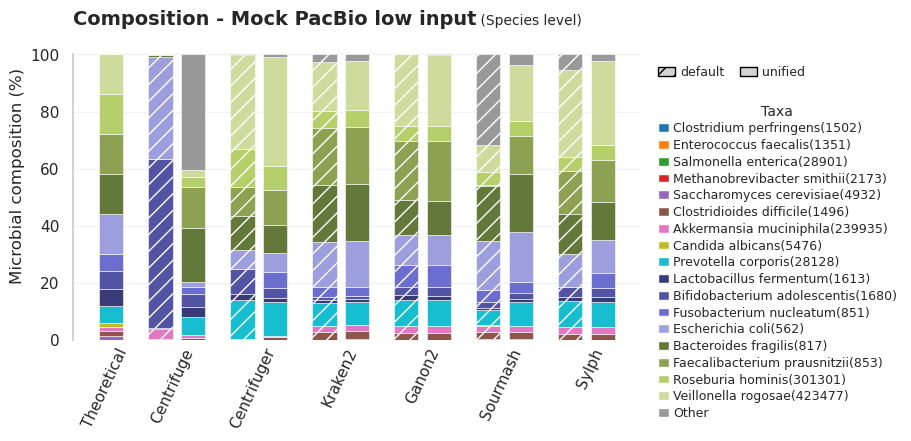

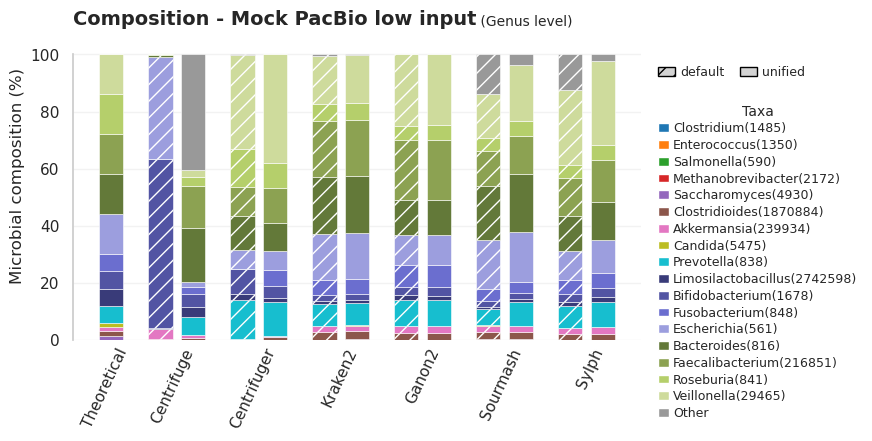

In [12]:
# Stacked relative-abundance bar plot.
# Default bars hatched, unified bars solid. ONE tick label per group
# (tool name, or "Theoretical" for the truth bar) — the hatching is
# explained by a single inset legend on the right. Title is placed
# inside the axes, left-aligned to the y-axis, so cropping the tick
# numbers (0/20/40…) preserves the title text.

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
import numpy as np
import pandas as pd


def _norm(x):
    s = float(x.sum())
    return x / s if s > 0 else x

for rank, payload in all_results.items():
    gt_df = payload["gt"]
    aligned_paths = payload.get("aligned_paths", {})
    if not aligned_paths:
        continue

    try:
        tool_order = [t for t in ORDER_TOOLDB if t in aligned_paths]
        if not tool_order:
            tool_order = list(aligned_paths)
    except NameError:
        tool_order = list(aligned_paths)

    # Group default+unified pairs by base tool so each tool's two bars are adjacent.
    pair_groups = {}
    for key in tool_order:
        base, _, suffix = key.rpartition("_")
        pair_groups.setdefault(base, {})[suffix] = key
    base_tools = list(pair_groups.keys())

    # Taxa stacking order (ascending by truth abundance), "Other" last.
    gt = gt_df.copy()
    gt["taxid"] = pd.to_numeric(gt["taxid"], errors="coerce").astype("Int64")
    gt["label"] = gt["name"].astype(str) + "(" + gt["taxid"].astype(int).astype(str) + ")"
    gt["abundance"] = pd.to_numeric(gt["abundance"], errors="coerce").fillna(0.0)
    taxa_order = (gt[["label", "abundance"]].groupby("label", as_index=False).sum()
                  .sort_values("abundance")["label"].tolist())
    if "Other" in taxa_order:
        taxa_order = [t for t in taxa_order if t != "Other"] + ["Other"]
    else:
        taxa_order = taxa_order + ["Other"]

    gt_vec = _norm(gt.groupby("label")["abundance"].sum().reindex(taxa_order, fill_value=0.0))
    gt_vec.name = "Theoretical"

    # Build (label, base, suffix) ordered list — Truth, then per tool: default, unified.
    rows = [gt_vec]
    bar_meta = [("Theoretical", "Theoretical", None)]
    for base in base_tools:
        for suffix in ("default", "unified"):
            key = pair_groups[base].get(suffix)
            if key is None:
                continue
            aligned = pd.read_csv(aligned_paths[key])
            labels = aligned["label"].astype(str)
            vals = aligned["pred"].astype(float)
            labels = labels.where(labels.isin(taxa_order), "Other")
            vec = _norm(vals.groupby(labels).sum().reindex(taxa_order, fill_value=0.0))
            vec.name = f"{base}_{suffix}"
            rows.append(vec)
            bar_meta.append((vec.name, base, suffix))
    big = pd.DataFrame(rows)

    # X positions — each tool pair is one tight cluster; bigger gap between tools.
    BAR_W = 0.15
    INNER = 0.20   # space within a default+unified pair
    OUTER = 0.10   # space between tools
    TRUTH_GAP = 0.30

    pos = []
    cur = 0.0
    seen_base = set()
    for name, base, suffix in bar_meta:
        if base == "Theoretical":
            pos.append(cur)
            cur += TRUTH_GAP
            continue
        if base not in seen_base:
            if seen_base:
                cur += OUTER
            seen_base.add(base)
        pos.append(cur)
        cur += INNER

    # Per-taxon colours — pull from tab20/tab20b/tab20c but skip near-grey
    # entries so no taxon collides with "Other" (which stays solid grey).
    taxa_no_other = [t for t in taxa_order if t != "Other"]

    def _build_palette(n):
        """Build a list of n visually distinct, non-grey colours. Saturated
        entries are used first (tab20 even indices, then tab20b/tab20c) so
        adjacent taxa land on perceptually different hues; pastel variants
        (tab20 odd indices) are only used as a last-resort fallback."""
        def _ok(c):
            # Skip near-grey (R, G, B within 0.10 of each other).
            return max(c[:3]) - min(c[:3]) >= 0.10
        palette = []
        # Pass 1: saturated tab20 (even indices), then all of tab20b, tab20c.
        for cmap_name, idx_iter in (
            ("tab20",  range(0, 20, 2)),
            ("tab20b", range(20)),
            ("tab20c", range(20)),
        ):
            _cm = plt.get_cmap(cmap_name)
            for i in idx_iter:
                c = _cm(i)
                if _ok(c):
                    palette.append(c)
                    if len(palette) >= n:
                        return palette
        # Pass 2: fall back to tab20 pastels (odd indices) only if still short.
        _cm = plt.get_cmap("tab20")
        for i in range(1, 20, 2):
            c = _cm(i)
            if _ok(c):
                palette.append(c)
                if len(palette) >= n:
                    return palette
        return palette

    _palette = _build_palette(len(taxa_no_other))
    color_map = {t: _palette[i % len(_palette)] for i, t in enumerate(taxa_no_other)}
    color_map["Other"] = (0.6, 0.6, 0.6, 1.0)

    fig_width = max(8, cur * 1.5)
    fig, ax = plt.subplots(figsize=(fig_width, 4.5))

    bottom = np.zeros(len(pos))
    for taxon in taxa_order:
        heights = big[taxon].values if taxon in big.columns else np.zeros(len(pos))
        for i, suffix in enumerate(m[2] for m in bar_meta):
            ax.bar(pos[i], heights[i], width=BAR_W, bottom=bottom[i],
                   color=color_map[taxon], edgecolor="white", linewidth=0.4,
                   hatch="//" if suffix == "default" else None)
        bottom += heights

    # ONE tick label per tool group (or "Truth" for the theoretical bar).
    tick_pos, tick_lbl = [], []
    for base in (["Theoretical"] + base_tools):
        xs = [pos[i] for i, (_, b, _) in enumerate(bar_meta) if b == base]
        if not xs:
            continue
        tick_pos.append(np.mean(xs))
        tick_lbl.append("Truth" if base == "Theoretical" else base)
    tick_lbl = ["Theoretical" if t == "Truth" else t for t in tick_lbl]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lbl, rotation=65, ha="right", fontsize=11)
    ax.tick_params(axis="x", length=0, pad=4)
    # Shift the tool name labels further right of each tick.
    _dx_tools = mtransforms.ScaledTranslation(14 / 72, 0, fig.dpi_scale_trans)
    for _lbl in ax.get_xticklabels():
        _lbl.set_transform(_lbl.get_transform() + _dx_tools)

    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Microbial composition (%)", fontsize=12)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_yticklabels([f"{int(t*100)}" for t in np.arange(0, 1.01, 0.2)])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.spines["left"].set_visible(True)
    # Keep the y-axis line from extending up into the title headroom (0-100% only).
    ax.spines["left"].set_bounds(0, 1.0)
    # Suppress x-axis gridlines (they were extending up through the title area).
    ax.grid(False)
    ax.yaxis.grid(True, alpha=0.25)
    ax.xaxis.grid(False)
    ax.xaxis.set_ticks_position("none")

    # Hatch legend — single horizontal row, outside the axes on the right,
    # above the Taxa legend. Stays out of the title's way; survives a crop
    # that only trims the left tick numbers.
    hatch_handles = [
        mpatches.Patch(facecolor="lightgrey", edgecolor="black", hatch="//", label="default"),
        mpatches.Patch(facecolor="lightgrey", edgecolor="black", label="unified"),
    ]
    hatch_leg = ax.legend(handles=hatch_handles, loc="upper left",
                          bbox_to_anchor=(1.01, 1.0 / 1.15),
                          bbox_transform=ax.transAxes,
                          fontsize=9, frameon=False, ncol=2,
                          handlelength=1.4, handletextpad=0.4, columnspacing=1.2)
    ax.add_artist(hatch_leg)

    plt.subplots_adjust(left=0.07, right=0.78, top=0.95, bottom=0.22)

    # Measure where the rotated tool-name tick labels end (in axes coords) so
    # we can bottom-align the Taxa legend with them.
    fig.canvas.draw()
    _renderer = fig.canvas.get_renderer()
    _inv_ax = ax.transAxes.inverted()
    _tick_bottoms = []
    for _lbl in ax.get_xticklabels():
        _bb = _lbl.get_window_extent(renderer=_renderer)
        _, _y_ax = _inv_ax.transform((0, _bb.y0))
        _tick_bottoms.append(_y_ax)
    _taxa_bottom_ax = min(_tick_bottoms) if _tick_bottoms else -0.10

    # Taxa legend — anchored so its BOTTOM sits at the bottom of the tool labels.
    taxa_handles = [mpatches.Patch(facecolor=color_map[t]) for t in taxa_order]
    ax.legend(taxa_handles, taxa_order,
              bbox_to_anchor=(1.01, _taxa_bottom_ax), loc="lower left",
              fontsize=9, title="Taxa", title_fontsize=10, frameon=False,
              handlelength=0.9, handletextpad=0.3, labelspacing=0.3)

    # Single-line title INSIDE the axes, left edge flush with the y-axis.
    # ZymoMockD6331 is shortened to "Zymo mock" so the (Rank level) subtitle
    # fits on the same line. Bold 14pt main + plain 10pt subtitle on the
    # same baseline (measure-and-place).
    _title_short = DISPLAY_TITLE.replace("ZymoMockD6331", "Mock")
    _main_t = ax.text(0.0, 0.96,
                      f"Composition - {_title_short}",
                      transform=ax.transAxes,
                      ha="left", va="baseline",
                      fontsize=14, fontweight="bold")
    fig.canvas.draw()
    _r2 = fig.canvas.get_renderer()
    _inv2 = ax.transAxes.inverted()
    _bb = _main_t.get_window_extent(renderer=_r2)
    _x1_ax = _inv2.transform((_bb.x1, 0))[0]
    ax.text(_x1_ax, 0.96,
            f" ({rank.capitalize()} level)",
            transform=ax.transAxes,
            ha="left", va="baseline", fontsize=10)

    if SAVE:
        out = FIGURES_DIR / f"{SAMPLE_LABEL}_{rank}_{MIN_ABUNDANCE}_stacked.png"
        save_fig(fig, out, SAVE, dpi=200, bbox_inches="tight")
        print(f"[stacked] Saved: {out}")
    plt.show(fig); plt.close(fig)


## 10. Combined metrics figure

/tmp/ipykernel_1863952/1493738240.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.01, 0.05, 0.995, 0.85])


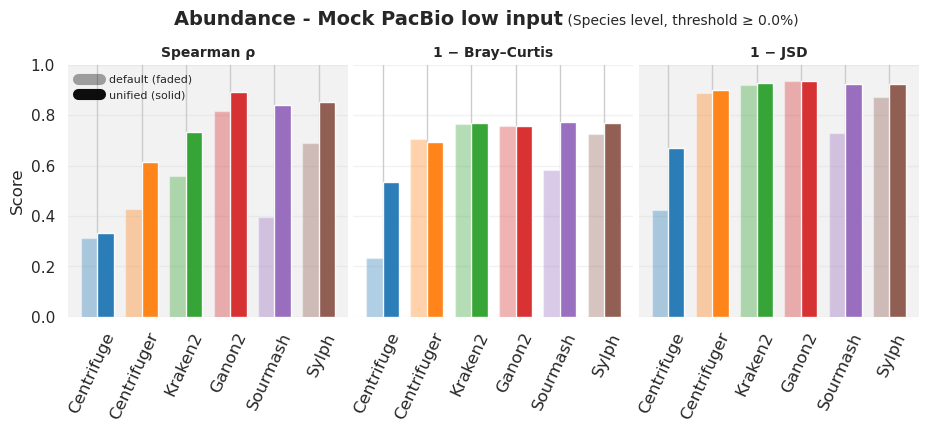

/tmp/ipykernel_1863952/1493738240.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.01, 0.05, 0.995, 0.85])


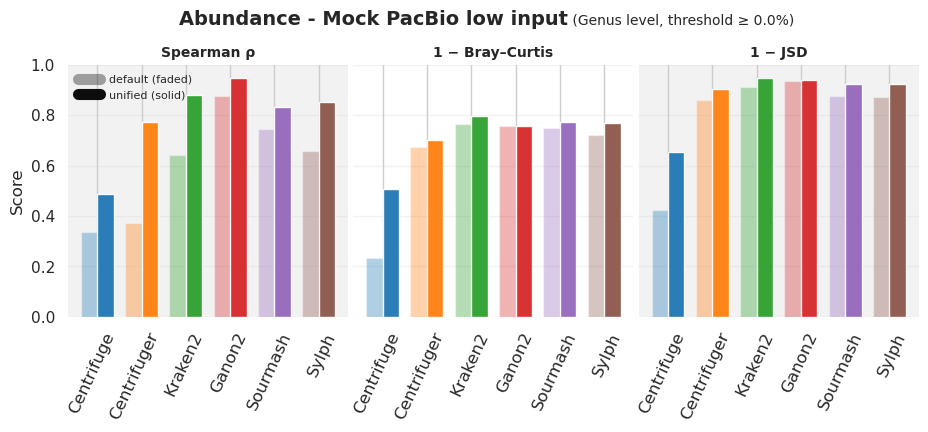

In [13]:
# Combined metrics: Spearman ρ, 1−Bray–Curtis, 1−JSD
import matplotlib.transforms as mtransforms

# Derive base-tool order from TOOLS (preserving order of first appearance)
BASE_TOOL_ORDER = []
for td in TOOLS:
    base = td.rsplit("_", 1)[0]
    if base not in BASE_TOOL_ORDER:
        BASE_TOOL_ORDER.append(base)

# Assign a consistent color per base tool
cmap = plt.get_cmap("tab10")
TOOL_COLORS = {tool: cmap(i % 10) for i, tool in enumerate(BASE_TOOL_ORDER)}

for rank, payload in all_results.items():
    aligned_paths = payload.get("aligned_paths", {})
    if not aligned_paths:
        print(f"[combined-metrics] No aligned tables for rank={rank}; skipping.")
        continue

    rows = []
    for key, aligned_path in aligned_paths.items():
        aligned = pd.read_csv(aligned_path)

        # ---------------- FILTER ZERO-ABUNDANCE TAXA ----------------
        # If threshold == 0: keep only taxa where either gt or pred is nonzero.
        # If threshold > 0: keep taxa where either gt or pred >= threshold.
        if MIN_ABUNDANCE == 0:
            aligned = aligned[(aligned["gt"] > 0) | (aligned["pred"] > 0)].copy()
        else:
            # If MIN_ABUNDANCE is given as a percentage (e.g. 0.1 for 0.1%),
            # this will still work as long as gt/pred use the same scale.
            thr = MIN_ABUNDANCE / 100.0 if MIN_ABUNDANCE > 1 else MIN_ABUNDANCE
            aligned = aligned[(aligned["gt"] >= thr) | (aligned["pred"] >= thr)].copy()

        if aligned.empty:
            # No taxa pass the filter for this tool_db; skip it
            continue

        rho, _ = spearman_r(aligned["gt"], aligned["pred"])
        bc = bray_curtis_distance(aligned["gt"].values, aligned["pred"].values)
        jsd_val = jsd_distance(aligned["gt"].values, aligned["pred"].values, base=2)

        rows.append({
            "rank": rank,
            "dataset": DATASET,
            "tool_db": key,
            "spearman_rho": rho,
            "similarity_1_minus_BC": 1 - bc,
            "similarity_1_minus_JSD": 1 - jsd_val,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        continue

    # ----- Sort tools using ORDER_TOOLDB if available -----
    try:
        order = [t for t in ORDER_TOOLDB if t in df["tool_db"].tolist()]
        if not order:
            order = df["tool_db"].tolist()
    except NameError:
        order = df["tool_db"].tolist()

    df["tool_db"] = pd.Categorical(df["tool_db"], categories=order, ordered=True)
    df = df.sort_values("tool_db")

    # Derive base tool names
    tool_bases = [
        b for b in BASE_TOOL_ORDER
        if any(df["tool_db"].str.startswith(b + "_"))
    ]

    tool_colors = TOOL_COLORS

    # Helper to find values
    def get_val(key, base, suffix):
        name = f"{base}_{suffix}"
        r = df[df["tool_db"] == name]
        return np.nan if r.empty else r.iloc[0][key]

    metrics = [
        ("spearman_rho",         "Spearman ρ"),
        ("similarity_1_minus_BC", "1 − Bray–Curtis"),
        ("similarity_1_minus_JSD", "1 − JSD"),
    ]

    x = np.arange(len(tool_bases)) * 0.35
    width = 0.13

    fig, axes = plt.subplots(
        1, 3, figsize=(9, 4), sharey=True, gridspec_kw={"wspace": 0.02}
    )

    plt.subplots_adjust(left=0.07, right=0.98, top=0.82, bottom=0.25, wspace=0.02)

    for i, (ax, (metric_key, metric_label)) in enumerate(zip(axes, metrics)):

        # alternating background shading
        ax.set_facecolor("#f2f2f2" if i % 2 == 0 else "white")

        for j, base in enumerate(tool_bases):
            color = tool_colors[base]

            # default faded
            ax.bar(
                x[j] - width/2,
                get_val(metric_key, base, "default"),
                width=width,
                color=color,
                alpha=0.35,
            )
            # unified solid
            ax.bar(
                x[j] + width/2,
                get_val(metric_key, base, "unified"),
                width=width,
                color=color,
                alpha=0.95,
            )

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.set_xticks(x)
        ax.set_xticklabels(tool_bases, rotation=65, ha="right", fontsize=12)
        # Shift tool names slightly to the right of each tick.
        _dx = mtransforms.ScaledTranslation(14 / 72, 0, fig.dpi_scale_trans)
        for _lbl in ax.get_xticklabels():
            _lbl.set_transform(_lbl.get_transform() + _dx)
        ax.set_title(metric_label, fontsize=10, fontweight="bold")
        ax.grid(axis="y", alpha=0.25)
        ax.set_ylim(0, 1.0)

    axes[0].set_ylabel("Score", fontsize=12)

    # === ONLY TWO LEGEND ENTRIES ===
    legend_handles = [
        plt.Line2D([0], [0], color="black", alpha=0.35, linewidth=8,
                   label="default (faded)"),
        plt.Line2D([0], [0], color="black", alpha=0.95, linewidth=8,
                   label="unified (solid)")
    ]
    axes[0].legend(
        handles=legend_handles,
        loc="upper left",
        fontsize=8,
        frameon=False
    )

    plt.subplots_adjust(wspace=0.02, left=0.05, right=0.995, top=0.83, bottom=0.20)
    plt.tight_layout(rect=[0.01, 0.05, 0.995, 0.85])

    # Single-line centered title: main (bold 14pt) + subtitle (plain 10pt) on
    # the same baseline. Render at x=0 first to measure widths, then center
    # the pair on the tight-bbox midpoint (so bbox_inches="tight" doesn't
    # shift the title off-center via asymmetric left/right cropping).
    _short_title = DISPLAY_TITLE.replace("ZymoMockD6331", "Mock")
    _main = fig.text(0, 0.93,
                     f"Abundance - {_short_title}",
                     ha="left", va="baseline", fontsize=14, fontweight="bold")
    _sub = fig.text(0, 0.93,
                    f" ({rank.capitalize()} level, threshold ≥ {MIN_ABUNDANCE}%)",
                    ha="left", va="baseline", fontsize=10)
    fig.canvas.draw()
    _renderer = fig.canvas.get_renderer()
    _fig_w_in = fig.get_size_inches()[0]
    _fig_w_px = _fig_w_in * fig.dpi
    _main_w = _main.get_window_extent(renderer=_renderer).width / _fig_w_px
    _sub_w  = _sub.get_window_extent(renderer=_renderer).width  / _fig_w_px
    _tight = fig.get_tightbbox(_renderer)
    _center = ((_tight.x0 + _tight.x1) / 2) / _fig_w_in
    # Nudge title slightly right of true centre.
    _shift_right = 0.025
    _left = _center - (_main_w + _sub_w) / 2 + _shift_right
    _main.set_x(_left)
    _sub.set_x(_left + _main_w)


    out_fig = FIGURES_DIR / f"{SAMPLE_LABEL}_{rank}_{MIN_ABUNDANCE}_spearman_braycurtis_jsd.png"
    save_fig(fig, out_fig, SAVE, dpi=300, bbox_inches="tight")
    plt.show(fig)
    plt.close(fig)


Generating single-bar plots for species...


/tmp/ipykernel_1863952/4187967819.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.01, 0.05, 0.995, 0.85])


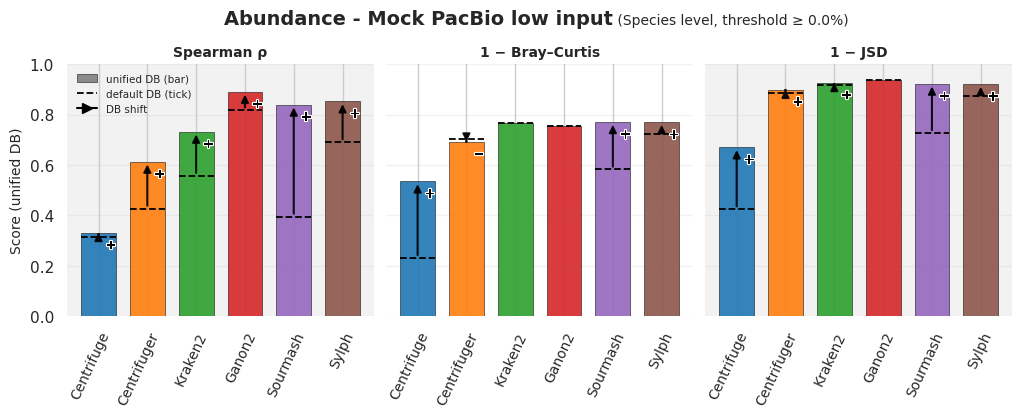


Generating single-bar plots for genus...


/tmp/ipykernel_1863952/4187967819.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.01, 0.05, 0.995, 0.85])


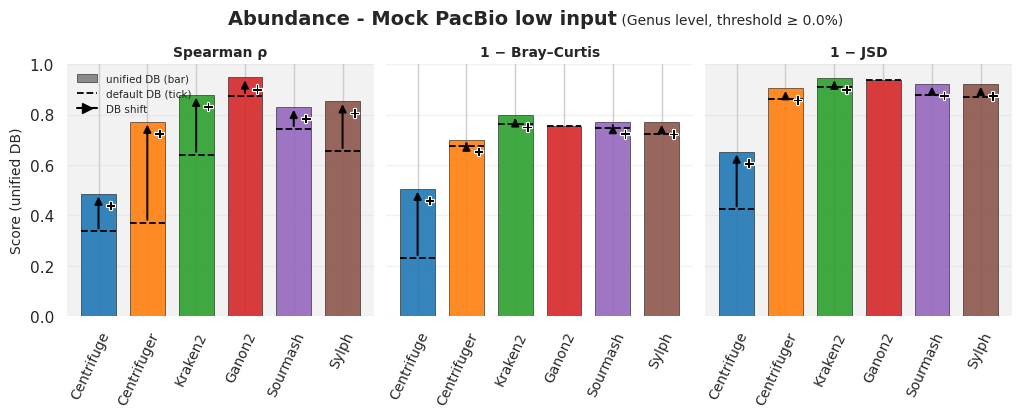

In [16]:
# ---- Single-bar plot: unified bar + default tick + DB-shift arrow ----

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.transforms as mtransforms
import numpy as np

METRIC_NAMES  = ["spearman", "one_minus_bc", "one_minus_jsd"]
METRIC_TITLES = ["Spearman ρ", "1 − Bray–Curtis", "1 − JSD"]

for rank, payload in all_results.items():
    aligned_paths = payload.get("aligned_paths", {})
    if not aligned_paths:
        continue

    print(f"\nGenerating single-bar plots for {rank}...")

    rows = []
    for key, aligned_path in aligned_paths.items():
        aligned = pd.read_csv(aligned_path)
        if MIN_ABUNDANCE == 0:
            aligned = aligned[(aligned["gt"] > 0) | (aligned["pred"] > 0)].copy()
        else:
            thr = MIN_ABUNDANCE / 100.0 if MIN_ABUNDANCE > 1 else MIN_ABUNDANCE
            aligned = aligned[(aligned["gt"] >= thr) | (aligned["pred"] >= thr)].copy()
        if aligned.empty:
            continue
        rho, _ = spearman_r(aligned["gt"], aligned["pred"])
        bc = bray_curtis_distance(aligned["gt"].values, aligned["pred"].values)
        jsd_val = jsd_distance(aligned["gt"].values, aligned["pred"].values, base=2)
        base, db = key.rsplit("_", 1)
        rows.append({
            "tool_db":      key,
            "base_tool":    base,
            "db_type":      db,
            "spearman":     rho,
            "one_minus_bc": 1 - bc,
            "one_minus_jsd": 1 - jsd_val,
        })
    metrics_df = pd.DataFrame(rows)
    if metrics_df.empty:
        continue

    base_tools = [t for t in BASE_TOOL_ORDER if (metrics_df["base_tool"] == t).any()]

    fig, axes = plt.subplots(
        1, 3,
        figsize=(10, 4),
        sharey=True,
        gridspec_kw={"wspace": 0.04},
    )

    x = np.arange(len(base_tools)) * 0.7

    for i, (ax, metric, title) in enumerate(zip(axes, METRIC_NAMES, METRIC_TITLES)):
        ax.set_facecolor("#f2f2f2" if i % 2 == 0 else "white")

        for j, base in enumerate(base_tools):
            row_def = metrics_df[(metrics_df["base_tool"] == base) & (metrics_df["db_type"] == "default")]
            row_uni = metrics_df[(metrics_df["base_tool"] == base) & (metrics_df["db_type"] == "unified")]
            if row_def.empty or row_uni.empty:
                continue
            d_val = float(row_def[metric].iloc[0])
            u_val = float(row_uni[metric].iloc[0])
            delta = u_val - d_val
            color = TOOL_COLORS[base]

            ax.bar(x[j], u_val, width=0.5, color=color, alpha=0.9,
                   edgecolor="black", linewidth=0.4, zorder=2)
            ax.hlines(d_val, x[j] - 0.25, x[j] + 0.25,
                      colors="black", linestyles="--", linewidth=1.3, zorder=3)

            if abs(delta) >= 0.005:
                ax.annotate("",
                            xy=(x[j], u_val), xytext=(x[j], d_val),
                            arrowprops=dict(arrowstyle="-|>", color="black",
                                            lw=1.5, mutation_scale=11, alpha=0.9),
                            zorder=4)
                sign = "+" if delta > 0 else "−"
                y_sign = max(u_val - 0.05, 0.02)
                t = ax.text(x[j] + 0.18, y_sign, sign,
                            ha="center", va="center",
                            fontsize=10, fontweight="bold",
                            color="black", zorder=5)
                t.set_path_effects([pe.withStroke(linewidth=1.6, foreground="white")])

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.set_xticks(x)
        ax.set_xticklabels(base_tools, rotation=65, ha="right", fontsize=10)
        _dx = mtransforms.ScaledTranslation(10 / 72, 0, fig.dpi_scale_trans)
        for _lbl in ax.get_xticklabels():
            _lbl.set_transform(_lbl.get_transform() + _dx)
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.grid(axis="y", alpha=0.25)
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_ylim(0, 1.0)

    axes[0].set_ylabel("Score (unified DB)", fontsize=10)

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="gray", edgecolor="black",
                      linewidth=0.4, alpha=0.9, label="unified DB (bar)"),
        plt.Line2D([0], [0], color="black", linestyle="--", linewidth=1.3,
                   label="default DB (tick)"),
        plt.Line2D([0], [0], color="black", marker=">", linestyle="-",
                   markersize=7, linewidth=1.5, label="DB shift"),
    ]
    axes[0].legend(handles=legend_handles, loc="upper left", frameon=False, fontsize=7.5)

    plt.subplots_adjust(wspace=0.02, left=0.05, right=0.995, top=0.83, bottom=0.20)
    plt.tight_layout(rect=[0.01, 0.05, 0.995, 0.85])

    _short_title = DISPLAY_TITLE.replace("ZymoMockD6331", "Mock")
    _main = fig.text(0, 0.93,
                     f"Abundance - {_short_title}",
                     ha="left", va="baseline", fontsize=14, fontweight="bold")
    _sub = fig.text(0, 0.93,
                    f" ({rank.capitalize()} level, threshold ≥ {MIN_ABUNDANCE}%)",
                    ha="left", va="baseline", fontsize=10)
    fig.canvas.draw()
    _renderer = fig.canvas.get_renderer()
    _fig_w_in = fig.get_size_inches()[0]
    _fig_w_px = _fig_w_in * fig.dpi
    _main_w = _main.get_window_extent(renderer=_renderer).width / _fig_w_px
    _sub_w  = _sub.get_window_extent(renderer=_renderer).width  / _fig_w_px
    _tight = fig.get_tightbbox(_renderer)
    _center = ((_tight.x0 + _tight.x1) / 2) / _fig_w_in
    _shift_right = 0.025
    _left = _center - (_main_w + _sub_w) / 2 + _shift_right
    _main.set_x(_left)
    _sub.set_x(_left + _main_w)

    fig_path = FIGURES_DIR / f"{SAMPLE_LABEL}_{rank}_{MIN_ABUNDANCE}_singlebar_delta.png"
    save_fig(fig, fig_path, SAVE, dpi=300, bbox_inches="tight")
    plt.show()

    if SAVE:
        print(f"Saved: {fig_path}")


## Debugging

In [15]:
TOOLS_TO_CHECK = ["Centrifuge_default", "Centrifuge_unified", "Sylph_default", "Sylph_unified"]

for rank in ["species", "genus"]:
    print("\n" + "="*100)
    print(f"DEBUG MISSING TRUE POSITIVES — RANK: {rank.upper()}")
    print("="*100)

    payload = all_results.get(rank)
    if payload is None:
        print(f"[{rank}] No payload found in all_results; skipping.")
        continue

    gt_df = payload["gt"].copy()
    gt_df["taxid"] = pd.to_numeric(gt_df["taxid"], errors="coerce").astype("Int64")

    tools = payload["tools"]

    for tool in TOOLS_TO_CHECK:
        print(f"\n--- {tool} @ {rank} ---")

        if tool not in tools:
            print(f"  Tool '{tool}' not found for this rank; skipping.")
            continue

        pred_df = tools[tool].copy()
        pred_df["taxid"] = pd.to_numeric(pred_df["taxid"], errors="coerce").astype("Int64")

        # True positives = intersection by taxid
        tp = gt_df.merge(pred_df, on="taxid", how="inner", suffixes=("_gt", "_pred"))
        tp_taxids = set(tp["taxid"])

        # False negatives = GT taxids not present in predictions
        gt_taxids = set(gt_df["taxid"])
        missing_taxids = sorted(gt_taxids - tp_taxids)

        print(f"  TP count: {len(tp_taxids)} / {len(gt_taxids)}")
        print(f"  FN (missing GT taxids): {len(missing_taxids)}")

        if missing_taxids:
            print("  → Missing GT taxa:")
            missing_df = gt_df[gt_df["taxid"].isin(missing_taxids)][["taxid", "name", "abundance"]]
            display(missing_df.sort_values("abundance", ascending=False))
        else:
            print("  → No missing GT taxa (perfect recall at this rank).")

        # Quick view of top TPs
        if len(tp) > 0:
            print("  Top recovered GT taxa:")
            cols = [c for c in ["taxid", "name_gt", "abundance_gt", "name_pred", "abundance_pred"] if c in tp.columns]
            display(tp[cols].sort_values("abundance_gt", ascending=False))


DEBUG MISSING TRUE POSITIVES — RANK: SPECIES

--- Centrifuge_default @ species ---
  TP count: 13 / 17
  FN (missing GT taxids): 4
  → Missing GT taxa:


,taxid,name,abundance
16,423477,Veillonella rogosae,14.0
12,28128,Prevotella corporis,6.0
11,5476,Candida albicans,1.5
10,4932,Saccharomyces cerevisiae,1.4


  Top recovered GT taxa:


,taxid,name_gt,abundance_gt,name_pred,abundance_pred
0,562,Escherichia coli,14.0000,Escherichia coli,35.790150
1,817,Bacteroides fragilis,14.0000,Bacteroides fragilis,0.750618
3,853,Faecalibacterium prausnitzii,14.0000,Faecalibacterium prausnitzii,0.005097
12,301301,Roseburia hominis,14.0000,Roseburia hominis,0.145265
2,851,Fusobacterium nucleatum,6.0000,Fusobacterium nucleatum,0.000000
7,1613,Lactobacillus fermentum,6.0000,Lactobacillus fermentum,0.440950
8,1680,Bifidobacterium adolescentis,6.0000,Bifidobacterium adolescentis,59.144030
11,239935,Akkermansia muciniphila,1.5000,Akkermansia muciniphila,3.300070
5,1496,Clostridioides difficile,1.5000,Clostridioides difficile,0.302832
9,2173,Methanobrevibacter smithii,0.1000,Methanobrevibacter smithii,0.042664



--- Centrifuge_unified @ species ---
  TP count: 17 / 17
  FN (missing GT taxids): 0
  → No missing GT taxa (perfect recall at this rank).
  Top recovered GT taxa:


...

,taxid,name_gt,abundance_gt,name_pred,abundance_pred
0,561,Escherichia,14.00,Escherichia,1.4093
2,816,Bacteroides,14.00,Bacteroides,1.6873
4,841,Roseburia,14.00,Roseburia,0.6077
9,29465,Veillonella,14.00,Veillonella,3.6590
10,216851,Faecalibacterium,14.00,Faecalibacterium,1.8246
3,838,Prevotella,6.00,Prevotella,1.1006
13,2742598,Limosilactobacillus,6.00,Limosilactobacillus,0.1778
5,848,Fusobacterium,6.00,Fusobacterium,0.6756
6,1678,Bifidobacterium,6.00,Bifidobacterium,0.4008
11,239934,Akkermansia,1.50,Akkermansia,0.2909



--- Sylph_unified @ genus ---
  TP count: 16 / 17
  FN (missing GT taxids): 1
  → Missing GT taxa:


,taxid,name,abundance
7,1485,Clostridium,0.0001


  Top recovered GT taxa:


,taxid,name_gt,abundance_gt,name_pred,abundance_pred
0,561,Escherichia,14.000,Escherichia,11.2640
2,816,Bacteroides,14.000,Bacteroides,13.4908
4,841,Roseburia,14.000,Roseburia,4.9353
11,29465,Veillonella,14.000,Veillonella,29.5990
12,216851,Faecalibacterium,14.000,Faecalibacterium,14.7930
5,848,Fusobacterium,6.000,Fusobacterium,5.4953
7,1678,Bifidobacterium,6.000,Bifidobacterium,3.2295
3,838,Prevotella,6.000,Prevotella,8.8680
15,2742598,Limosilactobacillus,6.000,Limosilactobacillus,1.4324
14,1870884,Clostridioides,1.500,Clostridioides,2.0314
